Using 1-minute resolution crypto-trade/order-book information from $10$ crypto-pairs  over a $3$ month period we train
multi-band regressors to predict $1h$, $1d$, $1w$ ahead for
* the average minute-wise sales price

We will also extract trading targets
* triple barrier:
  * unrealized profit limit is achieved
  * unrealized loss limit is achieved
  * the position is held until maximum time without achieving either
* period-returns; i.e. given price at t0 what is respective price at tperiod, and the subsequent return

In [12]:
# Generate synthetic multi-band data
def create_data(seq_length, num_samples, num_bands):
    x = np.linspace(0, 2*np.pi, seq_length)
    data = np.array([[np.sin(x + np.random.uniform(0, 2*np.pi)) for _ in range(num_bands)] for _ in range(num_samples)])
    data = np.transpose(data, (0, 2, 1))
    return data[:, :-1, :], data[:, 1:, :]

seq_length = 50
num_samples = 1000
num_bands = 3  # Number of bands (features)
x, y = create_data(seq_length, num_samples, num_bands)
x = torch.tensor(x, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

# Split data into training and test sets
train_size = int(len(x) * 0.8)
test_size = len(x) - train_size
train_x, test_x = x[:train_size], x[train_size:]
train_y, test_y = y[:train_size], y[train_size:]

In [11]:
train_x.shape

torch.Size([800, 49, 3])

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Define the LSTM model
class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMRegressor, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out)
        return out


Epoch [20/200], Loss: 0.3674
Epoch [40/200], Loss: 0.1288
Epoch [60/200], Loss: 0.0327
Epoch [80/200], Loss: 0.0218
Epoch [100/200], Loss: 0.0183
Epoch [120/200], Loss: 0.0161
Epoch [140/200], Loss: 0.0144
Epoch [160/200], Loss: 0.0132
Epoch [180/200], Loss: 0.0120
Epoch [200/200], Loss: 0.0109


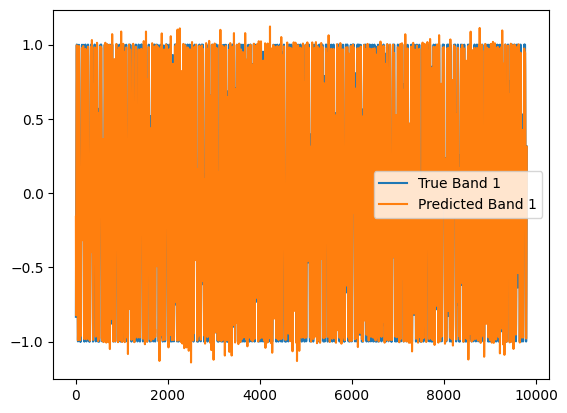

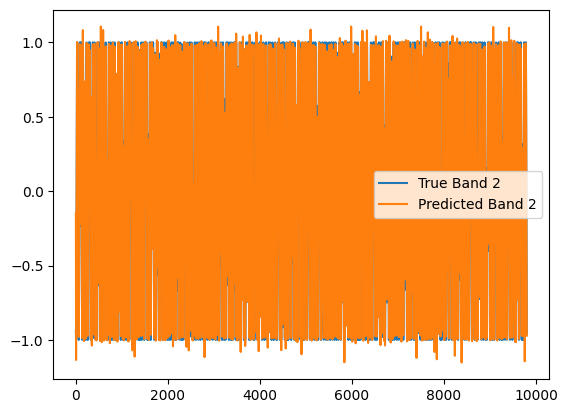

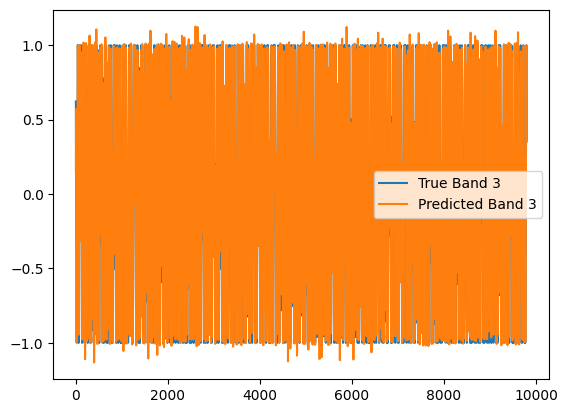

In [13]:

# Hyperparameters
input_size = num_bands
hidden_size = 64
num_layers = 2
output_size = num_bands #
num_epochs = 200
learning_rate = 0.001

# Model, loss function, and optimizer
model = LSTMRegressor(input_size, hidden_size, num_layers, output_size).to(torch.device("cpu"))
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Training the model
for epoch in range(num_epochs):
    model.train()
    outputs = model(train_x)
    optimizer.zero_grad()
    loss = criterion(outputs, train_y)
    loss.backward()
    optimizer.step()

    if (epoch+1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# Testing the model
model.eval()
with torch.no_grad():
    predicted = model(test_x).cpu().numpy()

# Plot the results for each band
for band in range(num_bands):
    plt.figure()
    plt.plot(test_y[:, :, band].cpu().numpy().flatten(), label=f'True Band {band+1}')
    plt.plot(predicted[:, :, band].flatten(), label=f'Predicted Band {band+1}')
    plt.legend()
    plt.show()